In [12]:
#librerías necesarias
import numpy as np
from sklearn.datasets import load_wine
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
#funciones para la generalización de kmeans

def distance(p1, p2):  # distancia euclidiana
    return np.sqrt(np.sum((p2 - p1)**2))

def compute_centroid(subdata): #función para calcular centroides
    subdata = np.array(subdata)
    c_x = np.sum(subdata[:,0]) / len(subdata)
    c_y = np.sum(subdata[:,1]) / len(subdata)
    return np.array([c_x, c_y])

#algoritmo de kmeans generalizado que devuelve los centroides finales y a que cluster pertenece cada punto (labels)
def kmeans(puntos, centroids, max_iter=100, tol=1e-3):
    for i in range(max_iter):
        labels = []
        new_centroids = []

        # Asignar cada punto al centroide más cercano
        for p in puntos:
            distances = [distance(p, c) for c in centroids]
            labels.append(np.argmin(distances))
        labels = np.array(labels)

        # Recalcular centroides
        for j in range(len(centroids)):
            cluster_points = puntos[labels == j]
            if len(cluster_points) > 0:
                new_centroids.append(compute_centroid(cluster_points))
            else:
                new_centroids.append(centroids[j])

        new_centroids = np.array(new_centroids)

        # Verificar convergencia
        shift = np.linalg.norm(new_centroids - centroids)
        if shift < tol:
            print(f"Convergencia alcanzada en {i+1} iteraciones.")
            break

        centroids = new_centroids

    return centroids, labels

def kmeans_plus_plus(X, k): #función para kmeans++
    n = len(X)
    centroids = []

    # primer centroide al azar
    idx = np.random.randint(0, n)
    centroids.append(X[idx])

    # seleccionar los siguientes k-1 centroides
    for _ in range(1, k):
        dists = np.array([min([distance(x, c) for c in centroids]) for x in X])
        probs = dists**2 / np.sum(dists**2)
        new_idx = np.random.choice(n, p=probs)
        centroids.append(X[new_idx])

    return np.array(centroids)

#wcss
def wcss(puntos, labels, centroids):
    total = 0
    k = len(centroids)
    for i in range(k):
        cluster = puntos[labels == i]
        for p in cluster:
            total += distance(p, centroids[i])**2
    return total

In [7]:
#dataset
data = load_wine()
X = data.data[:, :2]   #2 features para mantener la misma estructura del kmeans generalizado
y_true = data.target

Convergencia alcanzada en 2 iteraciones.
k=1, WCSS=337.55
Convergencia alcanzada en 11 iteraciones.
k=2, WCSS=168.08
Convergencia alcanzada en 4 iteraciones.
k=3, WCSS=95.55
Convergencia alcanzada en 6 iteraciones.
k=4, WCSS=73.09
Convergencia alcanzada en 4 iteraciones.
k=5, WCSS=65.44
Convergencia alcanzada en 9 iteraciones.
k=6, WCSS=53.50


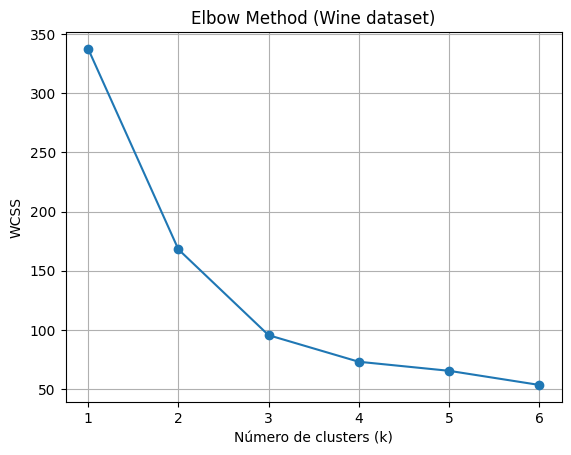

In [8]:
k_values = range(1, 7) #definimos un rango para la cantidad de clusters
wcss_values = []

for k in k_values:
    cent_init = kmeans_plus_plus(X, k)
    centroids, labels = kmeans(X, cent_init)
    wcss_values.append(wcss(X, labels, centroids))
    print(f"k={k}, WCSS={wcss_values[-1]:.2f}")

# Método del codo
plt.plot(k_values, wcss_values, marker='o')
plt.title("Elbow Method (Wine dataset)")
plt.xlabel("Número de clusters (k)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

En la gráfica se puede ver un codo en k=3

In [10]:
k = 3
cent_init = kmeans_plus_plus(X, k)
centroids, labels = kmeans(X, cent_init)

print("\nCentroides finales:", centroids)
print("WCSS final:", wcss(X, labels, centroids))

Convergencia alcanzada en 5 iteraciones.

Centroides finales: [[13.71538462  1.79969231]
 [12.21349206  1.6531746 ]
 [13.0632      3.8948    ]]
WCSS final: 95.5539420561661


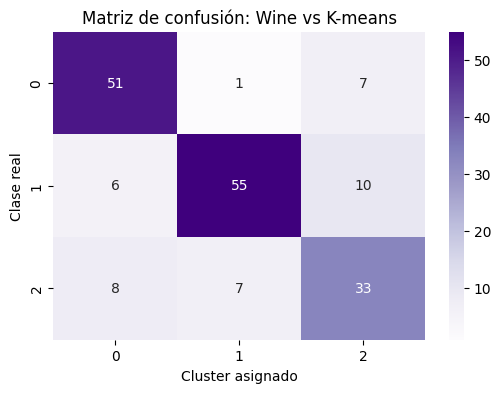

In [16]:
#comparación con labels reales

cm = confusion_matrix(y_true, labels)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
plt.xlabel("Cluster asignado")
plt.ylabel("Clase real")
plt.title("Matriz de confusión: Wine vs K-means")
plt.show()

La matriz de confusión muestra que K-means++ logra identificar correctamente la mayoría de los puntos de cada clase (diagonal principal), especialmente en las clases 0, para la clase 1 y 2 se presentaron más falsos negativos.